# Práctica 1: Perceptrón multicapa.

Tu jefe pidió a RH que recolectara datos de desempeño de tus compañeros, los resultados se almacenaron en un csv. El punto critico de estos datos es la satisfacción del empleado, entonces ¿Podremos estimar la satisfacción de los empleados con los datos recabados?.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models


df = pd.read_csv('Extended_Employee_Performance_and_Productivity_Data.csv')
df.info()

I0000 00:00:1780932875.111193     513 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780932875.962194     513 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780932884.633700     513 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  str    
 2   Gender                       100000 non-null  str    
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  str    
 5   Hire_Date                    100000 non-null  str    
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  str    
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  Sick_Days  

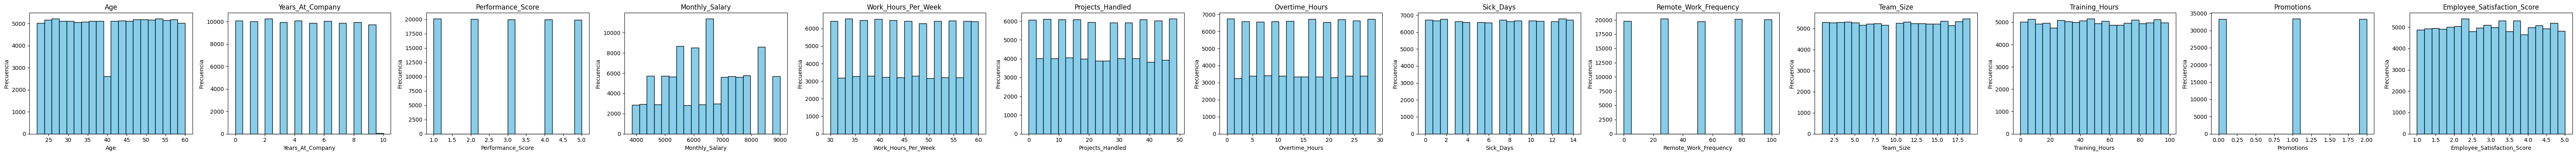

In [2]:
# Filtrar las columnas numéricas
numeric_columns = df.select_dtypes(include=['number']).drop('Employee_ID',axis=1)


# Si numeric_columns es un Index, conviértelo a lista
cols = list(numeric_columns)

fig, axes = plt.subplots(1, len(cols), figsize=(5 * len(cols), 4))

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Problemas**, tenemos distribuciones con picos, esos nos indica categorías. Por otro lado, tenemos variables con "valles" en su distribución (distribuciones multimodales) por lo que resultaría óptimo aplicar técnicas de feature engeneering. Por último tenemos distribuciones uniformes, por lo que cada una requeriría un procesamiento indivudual, hagamos la vista gorda e intentemos ajustar un MLP con estos datos, solo estandaricemos nuestros datos.

---

## Implementación de Red:

To**memos los datos numéricos como nuestra variable X, y la variable objetivo como ***'Employee_Satisfaction_Score'***.
- **Actividad 1**: Para todos los strings ``'@modif@'`` que aparescan en el siguiente bloque de código cámbialos para que el código funcione.

In [5]:
X = numeric_columns.drop('Employee_Satisfaction_Score', axis=1)
y = numeric_columns['Employee_Satisfaction_Score']
y = y.apply(lambda x: round(x)-1)  # Cambiamos la variable objetivo a 5 categorías numéricas

scaler = StandardScaler()
X_standar = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_standar, y, test_size=0.33, random_state=42)

y_onehot_train = tf.keras.utils.to_categorical(y_train, 5)
y_onehot_test = tf.keras.utils.to_categorical(y_test, 5)
print('X_train shape:', X_train.shape)
print('y_onehot_train shape:', y_onehot_train.shape)

X_train shape: (67000, 12)
y_onehot_train shape: (67000, 5)


- **Actividad 2:** Implementa 3 arquitecturas de MLP, cada una con su propio nombre, cambiando la estructura de dichas arquitecturas (capas, neuronas por capa, función de activación, etc). 

In [ ]:
# En las siguientes celdas, construye tu modelo con tensorflow.keras solo la arquitectura

In [10]:
n_features = X_train.shape[1]

model_1 = models.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(5, activation='softmax')
], name='MLP_Simple')

model_1.summary()

Model: "MLP_Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,029 (4.02 KB)

 Trainable params: 1,029 (4.02 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model_2 = models.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(5, activation='softmax')
], name='MLP_Profunda_Dropout')

model_2.summary()

Model: "MLP_Profunda_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,933 (50.52 KB)

 Trainable params: 12,549 (49.02 KB)

 Non-trainable params: 384 (1.50 KB)

In [12]:
model_3 = models.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(256, activation='tanh'),
    layers.Dense(128, activation='tanh'),
    layers.Dense(64, activation='tanh'),
    layers.Dense(32, activation='tanh'),
    layers.Dense(5, activation='softmax')
], name='MLP_Tanh_Ancha')

model_3.summary()

Model: "MLP_Tanh_Ancha"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 256)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,725 (182.52 KB)

 Trainable params: 46,725 (182.52 KB)

 Non-trainable params: 0 (0.00 B)

- **Actividad 3:** Compila y ajusta tus tres modelos con sus respectivos hiperparámetros.

In [ ]:
# En las siguientes celdas, compila y entrena el modelo

In [13]:
model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_1 = model_1.fit(
    X_train, y_onehot_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_onehot_test),
    verbose=1
)

loss_1, acc_1 = model_1.evaluate(X_test, y_onehot_test, verbose=0)
print(f'\nModelo 1 - Loss: {loss_1:.4f} | Accuracy: {acc_1:.4f}')

Epoch 1/30
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2536 - loss: 1.5664 - val_accuracy: 0.2539 - val_loss: 1.5608
Epoch 2/30
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2593 - loss: 1.5564 - val_accuracy: 0.2523 - val_loss: 1.5591
Epoch 3/30
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2607 - loss: 1.5551 - val_accuracy: 0.2501 - val_loss: 1.5586
Epoch 4/30
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2617 - loss: 1.5543 - val_accuracy: 0.2520 - val_loss: 1.5587
Epoch 5/30
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2652 - loss: 1.5538 - val_accuracy: 0.2502 - val_loss: 1.5587
Epoch 6/30
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2641 - loss: 1.5532 - val_accuracy: 0.2515 - val_loss: 1.5590
Epoch 7/30
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2656 - loss: 1.5528 - val_accuracy: 0.2503 - val_loss: 1.5591
Epoch 8/30
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2668 - loss: 1.5524 - 

In [16]:
model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_2 = model_2.fit(
    X_train, y_onehot_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_test, y_onehot_test),
    verbose=1
)

loss_2, acc_2 = model_2.evaluate(X_test, y_onehot_test, verbose=0)
print(f'\nModelo 2 - Loss: {loss_2:.4f} | Accuracy: {acc_2:.4f}')


Epoch 1/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2683 - loss: 1.5519 - val_accuracy: 0.2567 - val_loss: 1.5587
Epoch 2/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2713 - loss: 1.5512 - val_accuracy: 0.2571 - val_loss: 1.5588
Epoch 3/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2716 - loss: 1.5515 - val_accuracy: 0.2555 - val_loss: 1.5591
Epoch 4/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2707 - loss: 1.5511 - val_accuracy: 0.2558 - val_loss: 1.5588
Epoch 5/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2705 - loss: 1.5514 - val_accuracy: 0.2560 - val_loss: 1.5591
Epoch 6/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2735 - loss: 1.5506 - val_accuracy: 0.2555 - val_loss: 1.5592
Epoch 7/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2713 - loss: 1.5505 - val_accuracy: 0.2560 - val_loss: 1.5596
Epoch 8/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2733 - loss: 1.5504 - val_accuracy: 0.

In [17]:
model_3.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_3 = model_3.fit(
    X_train, y_onehot_train,
    epochs=30,
    batch_size=256,
    validation_data=(X_test, y_onehot_test),
    verbose=1
)

loss_3, acc_3 = model_3.evaluate(X_test, y_onehot_test, verbose=0)
print(f'\nModelo 3 - Loss: {loss_3:.4f} | Accuracy: {acc_3:.4f}')

Epoch 1/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2530 - loss: 1.5655 - val_accuracy: 0.2540 - val_loss: 1.5616
Epoch 2/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2535 - loss: 1.5594 - val_accuracy: 0.2554 - val_loss: 1.5610
Epoch 3/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2584 - loss: 1.5577 - val_accuracy: 0.2509 - val_loss: 1.5608
Epoch 4/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2570 - loss: 1.5572 - val_accuracy: 0.2492 - val_loss: 1.5602
Epoch 5/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2564 - loss: 1.5567 - val_accuracy: 0.2518 - val_loss: 1.5593
Epoch 6/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2584 - loss: 1.5558 - val_accuracy: 0.2522 - val_loss: 1.5597
Epoch 7/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2609 - loss: 1.5556 - val_accuracy: 0.2518 - val_loss: 1.5590
Epoch 8/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2600 - loss: 1.5554 - val_accuracy: 0.

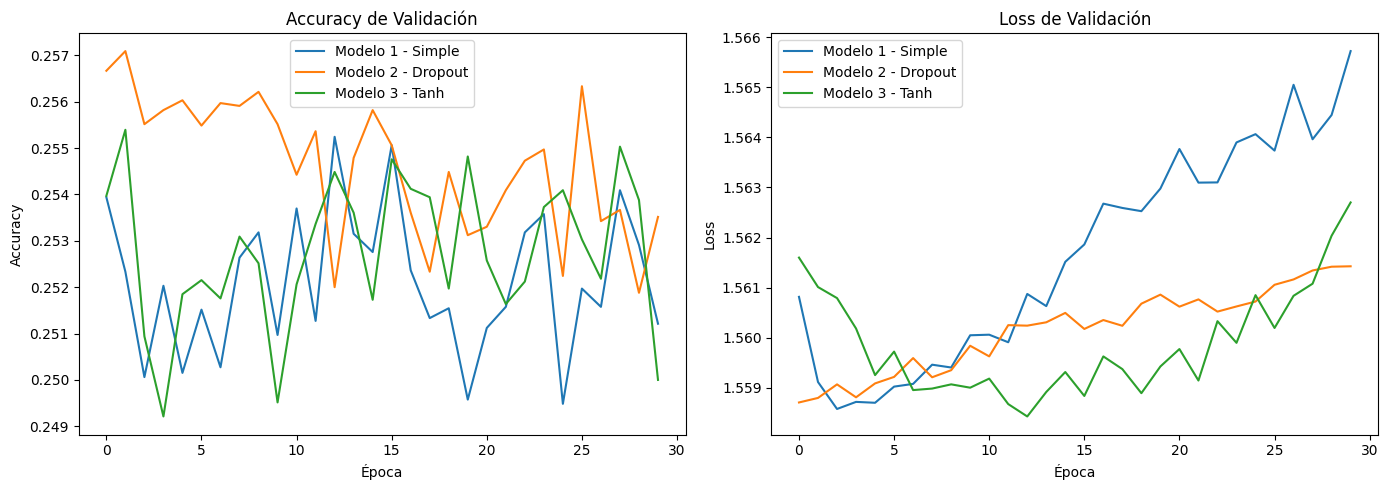


Resumen final:
Modelo 1 (Simple):   Accuracy=0.2512
Modelo 2 (Dropout):  Accuracy=0.2535
Modelo 3 (Tanh):     Accuracy=0.2500


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_1.history['val_accuracy'], label='Modelo 1 - Simple')
axes[0].plot(history_2.history['val_accuracy'], label='Modelo 2 - Dropout')
axes[0].plot(history_3.history['val_accuracy'], label='Modelo 3 - Tanh')
axes[0].set_title('Accuracy de Validación')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history_1.history['val_loss'], label='Modelo 1 - Simple')
axes[1].plot(history_2.history['val_loss'], label='Modelo 2 - Dropout')
axes[1].plot(history_3.history['val_loss'], label='Modelo 3 - Tanh')
axes[1].set_title('Loss de Validación')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nResumen final:')
print(f'Modelo 1 (Simple):   Accuracy={acc_1:.4f}')
print(f'Modelo 2 (Dropout):  Accuracy={acc_2:.4f}')
print(f'Modelo 3 (Tanh):     Accuracy={acc_3:.4f}')


- **Actividad 4:** Sube tus cambios al repositorio, envía el link de tu repositorio a la actividad 2 de tu checkpoint 2 y contesta las preguntas de dicha actividad.